# Trial run of reconstruction task with three models

In [1]:
import torch
from torch import nn
from torch import optim
from torch.utils.data import DataLoader, random_split
import torchaudio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import argparse
from torchinfo import summary
import torch.nn.functional as F

from A_00_models import CNNAutoencoder, ResLinearAutoencoder, LSTMAutoencoder
from model_configs import ModelDimConfigs, TrainingConfigs
from misc_tools import get_timestamp, ARPABET
from model_dataset import DS_Tools, Padder, TokenMap, NormalizerKeepShape
from model_dataset import SingleRecSelectBalanceDatasetPrecombine as ThisDataset
from model_filter import XpassFilter
from paths import *
from ssd_paths import *
from misc_progress_bar import draw_progress_bar
from misc_recorder import *
from H_11_drawer import draw_learning_curve_and_accuracy

### Testing

In [2]:
mytrans = nn.Sequential(
    Padder(sample_rate=TrainingConfigs.REC_SAMPLE_RATE, pad_len_ms=250, noise_level=1e-4), 
    torchaudio.transforms.MelSpectrogram(TrainingConfigs.REC_SAMPLE_RATE, 
                                        n_mels=TrainingConfigs.N_MELS, 
                                        n_fft=TrainingConfigs.N_FFT, 
                                        hop_length=TrainingConfigs.HOP_LENGTH, 
                                        power=2), 
    torchaudio.transforms.AmplitudeToDB(stype="power", top_db=80), 
    NormalizerKeepShape(NormalizerKeepShape.norm_mvn)
)

In [8]:
import math
def gen_tone(sr: int, duration_s: float = 0.25, freq: float = 440.0,
             amplitude: float = 0.2, phase: float = 0.0, noise_std: float = 0.0):
    """Pure sine with optional Gaussian noise. Returns (1, T) float32 in [-1, 1]."""
    T = int(round(sr * duration_s))
    t = torch.arange(T, dtype=torch.float32) / sr
    wave = amplitude * torch.sin(2 * math.pi * freq * t + phase)
    if noise_std > 0:
        wave = wave + noise_std * torch.randn_like(wave)
    return wave.unsqueeze(0)  # (channels=1, time)

wave = gen_tone(16000, duration_s=0.1, freq=440.0, amplitude=0.2, noise_std=0.0)
wave = wave.contiguous().to(dtype=torch.float32)

# Run through your preprocessing
with torch.no_grad():
    mel_db = mytrans(wave)  # shape should be (1, n_mels, n_frames)

print("Wave shape:", tuple(wave.shape))
print("Mel dB shape:", tuple(mel_db.shape))
print("Mel dB stats: min={:.2f}, max={:.2f}, mean={:.2f}".format(
    mel_db.min().item(), mel_db.max().item(), mel_db.mean().item())
)

Wave shape: (1, 1600)
Mel dB shape: (1, 64, 32)
Mel dB stats: min=-0.56, max=3.99, mean=-0.00


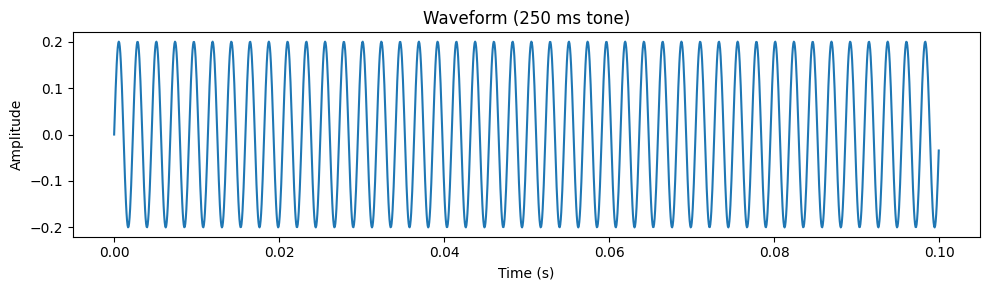

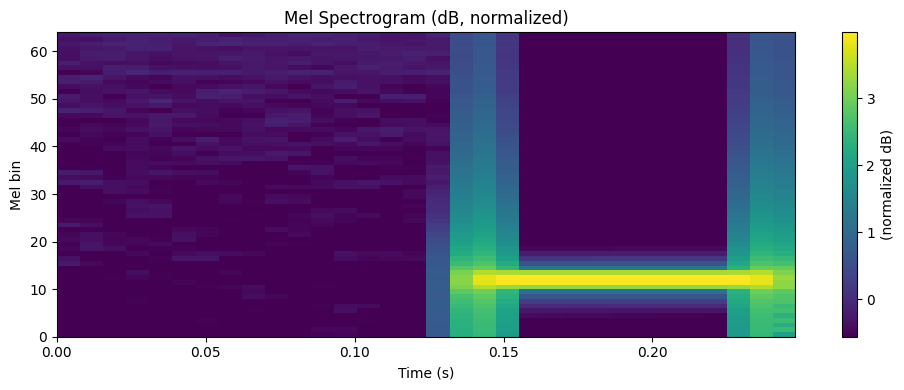

In [14]:
hop_length = 128
mel_for_plot = mel_db[0].cpu()                       # (n_mels, n_frames)
sr=16000
# --- 3) Build time axes for plotting ---
T = wave.shape[-1]
time_wave = torch.arange(T) / sr                           # seconds
n_frames = mel_for_plot.shape[-1]
time_mel = torch.arange(n_frames) * (hop_length / sr)      # seconds per frame
# (Optional) account for 'center=True' (frames centered by n_fft//2); we keep it simple here.

# --- 4) Plot waveform ---
plt.figure(figsize=(10, 3))
plt.plot(time_wave.numpy(), wave[0].cpu().numpy())
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Waveform (250 ms tone)")
plt.tight_layout()
plt.show()

# --- 5) Plot mel spectrogram (normalized dB) ---
plt.figure(figsize=(10, 4))
# imshow expects (rows, cols) -> (n_mels, n_frames)
plt.imshow(
    mel_for_plot.numpy(),
    origin="lower",
    aspect="auto",
    extent=[time_mel[0].item(), time_mel[-1].item() if n_frames > 1 else (time_mel[0] + 1e-9).item(), 0, mel_for_plot.shape[0]]
)
plt.xlabel("Time (s)")
plt.ylabel("Mel bin")
plt.title("Mel Spectrogram (dB, normalized)")
plt.colorbar(label="(normalized dB)")
plt.tight_layout()
plt.show()

### Load data

In [2]:
def load_data(hyper_dir, type="f", load="train"):
    if type == "l":
        mytrans = nn.Sequential(
            Padder(sample_rate=TrainingConfigs.REC_SAMPLE_RATE, pad_len_ms=250, noise_level=1e-4), 
            XpassFilter(cut_off_upper=500),
            torchaudio.transforms.MelSpectrogram(TrainingConfigs.REC_SAMPLE_RATE, 
                                                n_mels=TrainingConfigs.N_MELS, 
                                                n_fft=TrainingConfigs.N_FFT, 
                                                hop_length=TrainingConfigs.HOP_LENGTH,
                                                power=2), 
            torchaudio.transforms.AmplitudeToDB(stype="power", top_db=80), 
            NormalizerKeepShape(NormalizerKeepShape.norm_mvn)
        )
    elif type == "h": 
        mytrans = nn.Sequential(
            Padder(sample_rate=TrainingConfigs.REC_SAMPLE_RATE, pad_len_ms=250, noise_level=1e-4), 
            XpassFilter(cut_off_upper=10000, cut_off_lower=4000),
            torchaudio.transforms.MelSpectrogram(TrainingConfigs.REC_SAMPLE_RATE, 
                                                n_mels=TrainingConfigs.N_MELS, 
                                                n_fft=TrainingConfigs.N_FFT, 
                                                hop_length=TrainingConfigs.HOP_LENGTH,
                                                power=2), 
            torchaudio.transforms.AmplitudeToDB(stype="power", top_db=80), 
            NormalizerKeepShape(NormalizerKeepShape.norm_mvn)
        )
    else: 
        mytrans = nn.Sequential(
            Padder(sample_rate=TrainingConfigs.REC_SAMPLE_RATE, pad_len_ms=250, noise_level=1e-4), 
            torchaudio.transforms.MelSpectrogram(TrainingConfigs.REC_SAMPLE_RATE, 
                                                n_mels=TrainingConfigs.N_MELS, 
                                                n_fft=TrainingConfigs.N_FFT, 
                                                hop_length=TrainingConfigs.HOP_LENGTH,
                                                power=2), 
            torchaudio.transforms.AmplitudeToDB(stype="power", top_db=80), 
            NormalizerKeepShape(NormalizerKeepShape.norm_mvn)
        )
    with open(os.path.join(src_, "no-stress-seg.dict"), "rb") as file:
        # Load the object from the file
        mylist = pickle.load(file)
        mylist.remove('AH') # we don't include this, it is too mixed. 

    # Now you can use the loaded object
    mymap = TokenMap(mylist)
    if load == "train": 
        train_ds = ThisDataset(strain_cut_audio_, 
                            os.path.join(suse_, "guide_train.csv"), 
                            select=mylist, 
                            mapper=mymap, 
                            transform=mytrans)
        
        train_ds_indices = DS_Tools.read_indices(os.path.join(hyper_dir, f"train_full.use"))
        use_train_ds = torch.utils.data.Subset(train_ds, train_ds_indices)
        train_loader = DataLoader(use_train_ds, batch_size=TrainingConfigs.BATCH_SIZE, 
                                shuffle=True, 
                                num_workers=TrainingConfigs.LOADER_WORKER)
        
        return train_loader
    elif load == "valid":
        valid_ds = ThisDataset(strain_cut_audio_, 
                            os.path.join(suse_, "guide_validation.csv"), 
                            select=mylist, 
                            mapper=mymap,
                            transform=mytrans)
        valid_ds_indices = DS_Tools.read_indices(os.path.join(hyper_dir, f"valid_full.use"))
        use_valid_ds = torch.utils.data.Subset(valid_ds, valid_ds_indices)
        valid_loader = DataLoader(use_valid_ds, batch_size=TrainingConfigs.BATCH_SIZE, 
                                shuffle=False, 
                                num_workers=TrainingConfigs.LOADER_WORKER)
        return valid_loader


### Visualize results

In [3]:
def draw_loss(losses, epoch="", file_name=None): 

    train_losses, valid_losses, full_valid_losses = losses

    plt.clf()
    plt.figure()
    plt.plot(train_losses, label='Train')
    plt.plot(valid_losses, label='Valid')

    plt.title("Learning Curve Loss" + f" {epoch}")
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.xlabel("Epoch")

    display.clear_output(wait=True)
    display.display(plt.gcf())
    if file_name: 
        plt.savefig(file_name)

In [4]:
def draw_mel(src_mel, trg_mel, file_name=""):

    src_mel = src_mel.cpu().detach().numpy()
    trg_mel = trg_mel.cpu().detach().numpy()

    plt.clf()
    fig, axes = plt.subplots(1, 2)
    axes[0].imshow(src_mel[0], aspect='auto', origin='lower')
    axes[0].set_title("Source Mel")
    axes[1].imshow(trg_mel[0], aspect='auto', origin='lower')
    axes[1].set_title("Target Mel")

    display.clear_output(wait=True)
    display.display(plt.gcf())
    if file_name: 
        plt.savefig(file_name)

### Model parameters

In [7]:
input_shape = (128, 1, 64, 32)
cnn_hidden = 256
lstm_hidden = 128
n_filter_base = 4
n_filter_exp = 2
dropout_rate = 0.5

### Run once

In [5]:
def run_once(hyper_dir, model_type="", pretype="f", posttype="f", stage_epoch=15): 
    model_save_dir = os.path.join(hyper_dir, model_type, f"{pretype}{posttype}")
    mk(model_save_dir)

    # Loss Recording
    train_losses = ListRecorder(os.path.join(model_save_dir, "train.loss"))
    valid_losses = ListRecorder(os.path.join(model_save_dir, "valid.loss"))
    full_valid_losses = ListRecorder(os.path.join(model_save_dir, "full_valid.loss"))

    special_recs = DictRecorder(os.path.join(model_save_dir, "special.hst"))

    # Initialize Model
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    criterion = nn.MSELoss()
    if model_type == "cnn": 
        model = CNNAutoencoder(input_shape=input_shape)
    elif model_type == "reslin": 
        model = ResLinearAutoencoder(input_shape=input_shape)
    elif model_type == "lstm": 
        model = LSTMAutoencoder()
    else:
        raise Exception("Model not defined! ")
    
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    
    model_str = str(model)
    model_txt_path = os.path.join(model_save_dir, "model.txt")
    with open(model_txt_path, "w") as f:
        f.write(model_str)
        f.write("\n")
        f.write(str(summary(model, input_size=input_shape)))

    # Load Data (I&II)
    train_loader_1 = load_data(hyper_dir, type=pretype, load="train") # target training
    valid_loader_1 = load_data(hyper_dir, type=pretype, load="valid") # target validation
    train_loader_2 = load_data(hyper_dir, type=posttype, load="train") # full training
    valid_loader_2 = load_data(hyper_dir, type=posttype, load="valid") # full validation

    # Train (I)
    EPOCHS = stage_epoch
    BASE = 0

    for epoch in range(BASE, BASE + EPOCHS):
        # Train
        model.train()
        train_loss = 0.
        train_num = len(train_loader_1) # train_loader

        for idx, (x, _) in enumerate(train_loader_1):
            optimizer.zero_grad()
            x = x.to(device)
            x_rec = model(x).to(device)
            loss = criterion(x_rec, x)
            train_loss += loss.item()
            loss.backward()
            #torch.nn.utils.clip_grad_norm_(parameters=model.parameters(), max_norm=5, norm_type=2)
            optimizer.step()

        train_losses.append(train_loss / train_num)
        last_model_name = f"{epoch}.pt"
        torch.save(model.state_dict(), os.path.join(model_save_dir, last_model_name))

        # Target Eval
        model.eval()
        valid_loss = 0.
        valid_num = len(valid_loader_1) # target validation

        for idx, (x, _) in enumerate(valid_loader_1):
            x = x.to(device)
            x_rec = model(x).to(device)
            loss = criterion(x_rec, x)
            valid_loss += loss.item()

            # checking reconstruction quality with a random batch of data
            # for tuning hyperparameters
            if idx == 0:
                mel_name = f"{model_save_dir}/epoch_{epoch}_batch_{idx}_target.png"
                print(f"reconstruction loss: {loss.item()}")
                draw_mel(src_mel=x[0], trg_mel=x_rec[0], file_name=mel_name)

        valid_losses.append(valid_loss / valid_num)

        # Full Eval
        model.eval()
        full_valid_loss = 0.
        full_valid_num = len(valid_loader_2) # full validation
        for idx, (x, _) in enumerate(valid_loader_2):
            x = x.to(device)
            x_rec = model(x).to(device)
            loss = criterion(x_rec, x)
            full_valid_loss += loss.item()

            # checking reconstruction quality with a random batch of data
            # for tuning hyperparameters
            if idx == 0:
                mel_name = f"{model_save_dir}/epoch_{epoch}_batch_{idx}_full.png"
                print(f"reconstruction loss: {loss.item()}")
                draw_mel(src_mel=x[0], trg_mel=x_rec[0], file_name=mel_name)

        full_valid_losses.append(full_valid_loss / full_valid_num)

        train_losses.save()
        valid_losses.save()
        full_valid_losses.save()

    draw_loss(losses=(train_losses.get(), valid_losses.get(), full_valid_losses.get()), 
              epoch=str(BASE + EPOCHS - 1), 
              file_name=f"{model_save_dir}/loss.png")
    
    # Train (II)
    BASE = BASE + EPOCHS
    EPOCHS = stage_epoch
    valid_correct = 0
    valid_total = 0
    for epoch in range(BASE, BASE + EPOCHS):
        model.train()
        train_loss = 0.
        train_num = len(train_loader_2)    # train_loader
        for idx, (x, _) in enumerate(train_loader_2):
            optimizer.zero_grad()
            x = x.to(device)
            x_rec = model(x).to(device)
            loss = criterion(x_rec, x)
            train_loss += loss.item()
            loss.backward()
            #torch.nn.utils.clip_grad_norm_(parameters=model.parameters(), max_norm=5, norm_type=2)
            optimizer.step()

        train_losses.append(train_loss / train_num)
        last_model_name = f"{epoch}.pt"
        torch.save(model.state_dict(), os.path.join(model_save_dir, last_model_name))

        # Target Eval
        model.eval()
        valid_loss = 0.
        valid_num = len(valid_loader_2) # target validation is the same as full validation
        for idx, (x, y) in enumerate(valid_loader_2):
            x = x.to(device)
            x_rec = model(x).to(device)
            loss = criterion(x_rec, x)
            valid_loss += loss.item()

            # checking reconstruction quality with a random batch of data
            # for tuning hyperparameters
            if idx == 0:
                mel_name = f"{model_save_dir}/epoch_{epoch}_batch_{idx}_full.png"
                print(f"reconstruction loss: {loss.item()}")
                draw_mel(src_mel=x[0], trg_mel=x_rec[0], file_name=mel_name)

        valid_losses.append(valid_loss / valid_num)
        full_valid_losses.append(valid_loss / valid_num)

        train_losses.save()
        valid_losses.save()
        full_valid_losses.save()

    draw_loss(losses=(train_losses.get(), valid_losses.get(), full_valid_losses.get()), 
              epoch=str(BASE + EPOCHS - 1), 
              file_name=f"{model_save_dir}/loss.png")
    

### Main

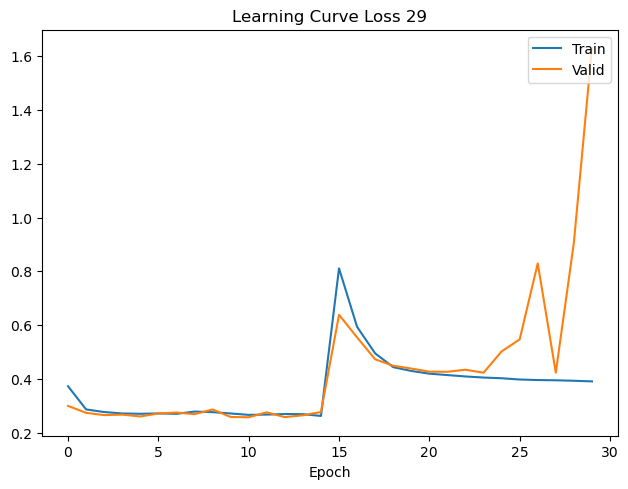

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

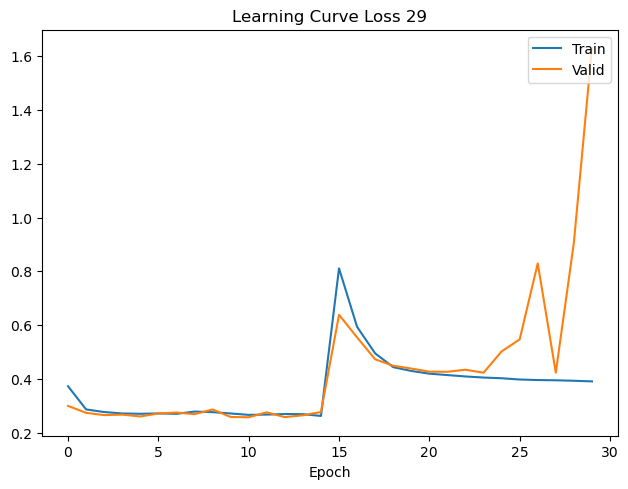

In [16]:
parser = argparse.ArgumentParser(description='argparse')
parser.add_argument('--dataprepare', '-dp', action="store_true")
parser.add_argument('--timestamp', '-ts', type=str, default="0000000000", help="Timestamp for project, better be generated by bash")
parser.add_argument('--gpu', '-gpu', type=int, default=0, help="Choose the GPU to work on")
parser.add_argument('--model','-m',type=str, default = "large",help="Model type: cnn, reslin, lstm")
parser.add_argument('--pretype','-p',type=str, default="f", help='Pretraining data type')

args = parser.parse_args(args=[#'--dataprepare',
                               '--timestamp', '08221130_15+15', '--gpu', 0, '--model', 'reslin', '--pretype', 'h'])

## Hyper-preparations
ts = args.timestamp
train_name = "REC"
hyper_dir = os.path.join(model_save_, f"{train_name}-{ts}")
print(f"{train_name}-{ts}")
mk(hyper_dir)

if args.dataprepare: 
    ### Get Data (Not Loading)
    with open(os.path.join(src_, "no-stress-seg.dict"), "rb") as file:
        # Load the object from the file
        mylist = pickle.load(file)
        mylist.remove("AH")

    train_ds = ThisDataset(strain_cut_audio_, 
                            os.path.join(suse_, "guide_train.csv"), 
                            select=mylist, 
                            mapper=TokenMap(mylist), 
                            transform=None)
    valid_ds = ThisDataset(strain_cut_audio_, 
                        os.path.join(suse_, "guide_validation.csv"), 
                        select=mylist, 
                        mapper=TokenMap(mylist),
                        transform=None)

    # train data
    use_len = int(0.01 * len(train_ds))
    remain_len = len(train_ds) - use_len
    use_train_ds, remain_ds = random_split(train_ds, [use_len, remain_len])

    # valid data
    use_len = int(0.01 * len(valid_ds))
    remain_len = len(valid_ds) - use_len
    use_valid_ds, remain_ds = random_split(valid_ds, [use_len, remain_len])

    # NOTE: we don't need to save the cut-small subset, because after cutting-small, 
    # the saved train and valid separations will reflect this
    DS_Tools.save_indices(os.path.join(hyper_dir, f"train_full.use"), use_train_ds.indices)
    DS_Tools.save_indices(os.path.join(hyper_dir, f"valid_full.use"), use_valid_ds.indices)
    print(len(use_train_ds), len(use_valid_ds))

else: 
    torch.cuda.set_device(args.gpu)
    run_once(hyper_dir, model_type=args.model, pretype=args.pretype, posttype="f", stage_epoch=15)